# COMP642 Machine Learning Final Project
Fantasy Football Wide Receiver (WR) Predictions\
James Jamgotchian\
S01436702

## Data
Data is sourced from the `nflreadpy` package available on the standard PyPI channel [and available on Github](https://github.com/nflverse/nflreadpy). It is a Python-port from the `nflverse-data` project which holds the [automated data releases of NFL data](https://github.com/nflverse/nflverse-data). 

In [1]:
# Basic imports to be used throughout this notebook
import nflreadpy as nfl
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

### 1. Get Data
----

#### Player Statistics Data

In [2]:
# Relevant columns for this model
COLS_TO_KEEP = ['player_id', 'player_name', 'player_display_name', 'position', 
                'season', 'week', 'season_type', 'team', 'opponent_team',
                'receptions', 'targets', 'receiving_yards', 'receiving_tds', 
                'receiving_air_yards', 'receiving_yards_after_catch', 
                'receiving_first_downs', 'receiving_epa', 'racr', 
                'target_share', 'air_yards_share', 'wopr', 
                'fantasy_points', 'fantasy_points_ppr'
               ]
# Load weekly stats for the last 3 seasons
seasons = [2023, 2024, 2025]
weekly_stats = nfl.load_player_stats(seasons)
weekly_stats = weekly_stats.select(COLS_TO_KEEP)

#### Player Identifying Data

In [3]:
PLAYER_COLS_TO_KEEP = ['gsis_id', 'height', 'weight', 'birth_date', 'years_of_experience']
df_players = nfl.load_players().to_pandas()
df_players = df_players[PLAYER_COLS_TO_KEEP]

#### Game Identifying Data

In [4]:
SCHED_COLS_TO_KEEP = ['season', 'week', 'home_team', 'away_team', 'gameday']
schedules = nfl.load_schedules(seasons).to_pandas()
# Only need season, week, and team to match the game date to the player
sched_lite = schedules[SCHED_COLS_TO_KEEP]

#### Filtering of data

In [5]:
## This model will only address WR's, and fantasy football only uses Regular Season games
# filter for WRs/Reg season and convert to Pandas
weekly_stats = weekly_stats.filter(weekly_stats['position'] == 'WR')
df_wr = weekly_stats.filter(weekly_stats['season_type'] == 'REG').to_pandas()

# Clean up by removing players who didn't actually play a snap
df_wr = df_wr[df_wr['receptions'] >= 0]

#### Aggregation of all data

In [6]:
## Firstly, Merge statistical data with player data
df_master = pd.merge(
    df_wr, 
    df_players, 
    left_on='player_id', 
    right_on='gsis_id', 
    how='left'
)

# remove extraneous columns
df_master = df_master.drop(columns=['gsis_id', 'player_name', 'position', 'season_type'])

# --------------------------------------------------------------------------------------
## Second, merge the schedule info with the rest of the data to get gameday information
# Note: A player could be on the home or away team. 
# merge based on the player's team matching either side.
df_master = pd.merge(
    df_master, 
    sched_lite, 
    left_on=['season', 'week', 'team'], 
    right_on=['season', 'week', 'home_team'], # Try matching as home team
    how='left'
)

# Fill in the blanks for Away games
df_master['gameday'] = df_master['gameday'].fillna(
    pd.merge(
        df_master, 
        sched_lite, 
        left_on=['season', 'week', 'team'], 
        right_on=['season', 'week', 'away_team'], 
        how='left'
    )['gameday_y']
)

# verify that 'gameday' field is fully populated
print(f'"gameday" field has {df_master['gameday'].isna().sum()} null values')
# drop unneeded 'home'/'away' for this model
df_master = df_master.drop(columns=['home_team', 'away_team'])

"gameday" field has 0 null values


### 2. Data Prep
-----

#### Check for Null Values

Columns with null values: ['receiving_epa', 'racr']
total null values: player_id                         0
player_display_name               0
season                            0
week                              0
team                              0
opponent_team                     0
receptions                        0
targets                           0
receiving_yards                   0
receiving_tds                     0
receiving_air_yards               0
receiving_yards_after_catch       0
receiving_first_downs             0
receiving_epa                  1038
racr                           1049
target_share                      0
air_yards_share                   0
wopr                              0
fantasy_points                    0
fantasy_points_ppr                0
height                            0
weight                            0
birth_date                        0
years_of_experience               0
gameday                           0
dtype: int64


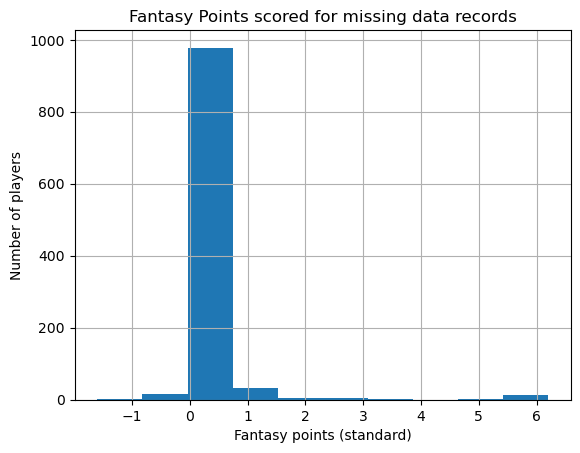

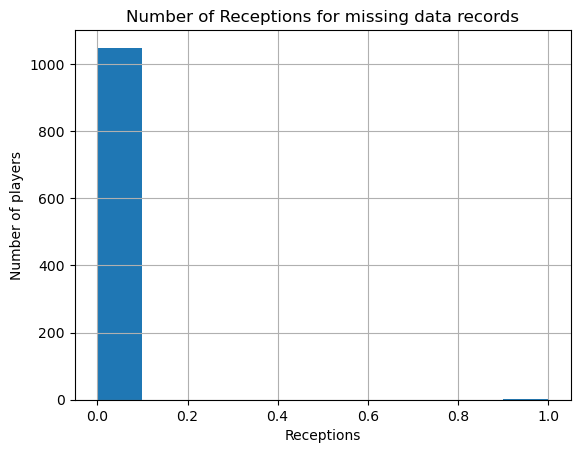

In [9]:
if (df_master.isna().any().any()):
    print(f'Columns with null values: {df_master.columns[df_master.isna().any()].tolist()}')
    print(f'total null values: {df_master.isna().sum()}')
    nv_present = True
else:
    print('No columns with null values detected.')

if nv_present:
    # plot the distribution of fantasy points for records with missing data
    # to determine their significance
    df_missing = df_master.loc[df_master.isna().any(axis=1), :]
    df_missing['fantasy_points'].hist(bins=10)
    plt.title('Fantasy Points scored for missing data records')
    plt.xlabel('Fantasy points (standard)')
    plt.ylabel('Number of players')
    # plot distribution of number of receptions for records with missing data
    plt.figure()
    df_missing['receptions'].hist(bins=10)
    plt.title('Number of Receptions for missing data records')
    plt.xlabel('Receptions')
    plt.ylabel('Number of players')

#### Null values resolution
- As can be seen by the two plots above, the records with missing data appear to have minimal fantasy scores and basically zero receptions (one of the key indicators that a WR played in the game.
- It is likely these records are incomplete or corrupted, and will be completely omitted from the rest of the ML process

In [13]:
# drop the missing data after resolving it is not valid for this analysis
print(f'Number of records prior to removing nulls {len(df_master)}')
df_master = df_master.dropna()
print(f'Number of records after removing nulls {len(df_master)}')

Number of records prior to removing nulls 6334
Number of records after removing nulls 6334


#### Feature Engineering
- Add additional features to data to increase its usefulness for the model
---

##### Feature 1 - `age_at_game`
- player's age at the time of the game

In [14]:
# Convert to Datetime
df_master['birth_date'] = pd.to_datetime(df_master['birth_date'])
df_master['gameday'] = pd.to_datetime(df_master['gameday'])

# Calculate Age in Years (floating point)
# We divide by 365.25 to account for leap years
df_master['age_at_game'] = (df_master['gameday'] - df_master['birth_date']).dt.days / 365.25

print(df_master[['player_display_name', 'season', 'week', 'age_at_game']].head())

  player_display_name  season  week  age_at_game
0        Randall Cobb    2023     1    33.054073
1        Marvin Jones    2023     1    33.489391
2        Adam Thielen    2023     1    33.051335
3    Marquise Goodwin    2023     1    32.807666
4        Keenan Allen    2023     1    31.370294


##### Feature 2 - True Target Variable - "Half PPR" fantasy points
- Most fantasy scores are "standard" or "PPR - Points per Reception". Half PPR is a mix of both and is a common balanced approach

In [22]:
# create "Half PPR" points since that is the true target
df_master['fantasy_points_half_ppr'] = df_master[['fantasy_points', 'fantasy_points_ppr']].mean(axis=1)

#### Data Transformations

In [ ]:
# TODO - add 1-hot encoding for non-numeric data
#      - or instead, convert the labels (player name, team, etc) into numeric data i.e. offensive team score/defensive team score
#      - add normalization

In [16]:
# sort chronologically by player and week
df_master = df_master.sort_values(['player_id', 'season', 'week'])

df_master.to_csv('WRs_2023-2025.csv')
print(f"Successfully loaded and saved {len(df_master)} game logs for Wide Receivers")

Successfully loaded and saved 6334 game logs for Wide Receivers


### 3. Data Visualization
----

In [17]:
print(len(df_master['player_display_name'].unique()))

319


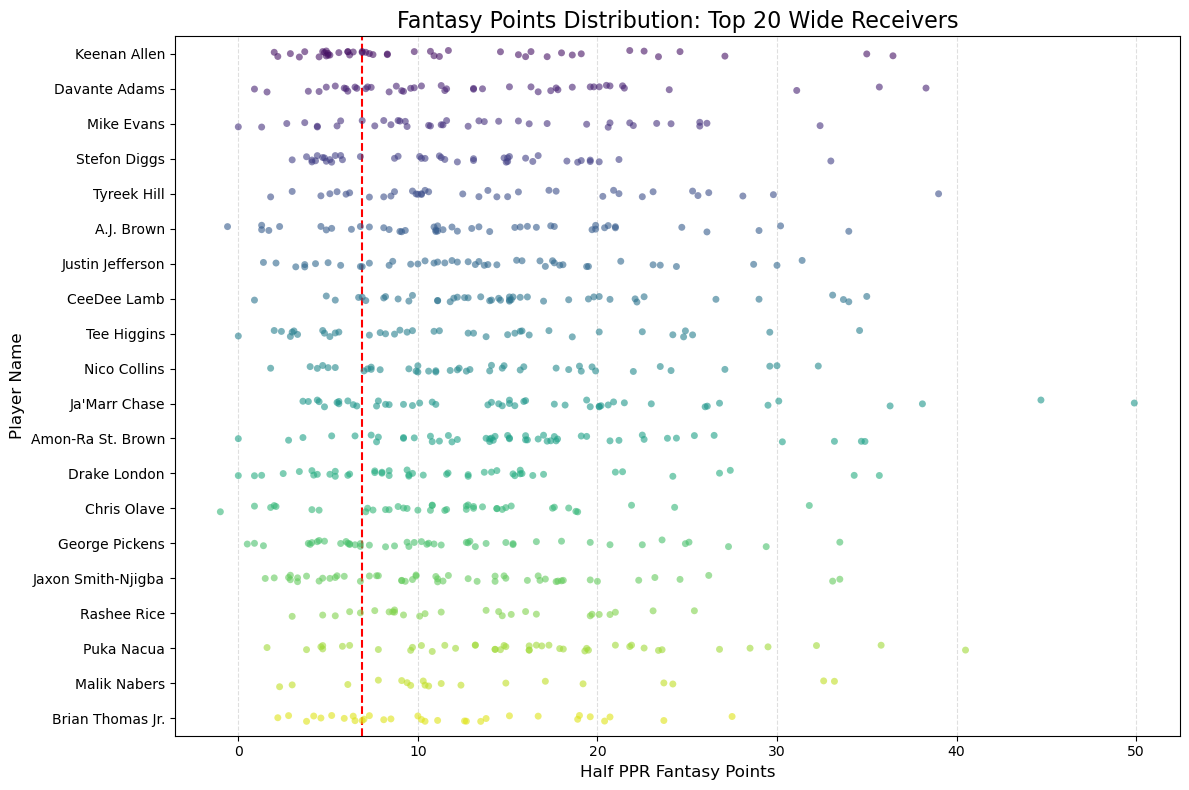

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify the top 20 WRs by average points to keep the chart readable
top_20_names = df_master.groupby('player_display_name')['fantasy_points_half_ppr'].mean().nlargest(20).index
df_plot = df_master[df_master['player_display_name'].isin(top_20_names)]

# 2. Create the Strip Plot
plt.figure(figsize=(12, 8))
sns.stripplot(
    data=df_plot, 
    x='fantasy_points_half_ppr', 
    y='player_display_name', 
    hue='player_display_name',  # Adds color variety
    jitter=True,        # Spreads dots out so they don't overlap perfectly
    alpha=0.6,          # Makes dots slightly transparent
    palette='viridis',
    legend=False
)

# 3. Add a Mean Line for context
plt.axvline(df_master['fantasy_points_half_ppr'].mean(), color='red', linestyle='--', label='League Average')

plt.title('Fantasy Points Distribution: Top 20 Wide Receivers', fontsize=16)
plt.xlabel('Half PPR Fantasy Points', fontsize=12)
plt.ylabel('Player Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

Text(0.5, 1.0, 'Distribution of WR Fantasy Points (The Regression Target)')

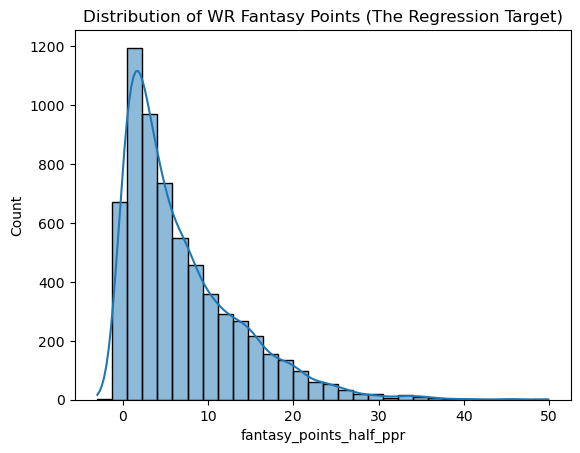

In [20]:
sns.histplot(df_master['fantasy_points_half_ppr'], bins=30, kde=True)
plt.title('Distribution of WR Fantasy Points (The Regression Target)')

In [21]:
import numpy as np

df_master = df_master.drop(columns=['player_id', 'player_display_name', 'team', 'opponent_team', 'birth_date'])
cov_matrix = df_master.cov()
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(cov_matrix, dtype=bool))

plt.figure()
sns.heatmap(cov_matrix, fmt='.1f', cmap='coolwarm', mask=mask, square=True)
plt.title('Masked Covariance Matrix')
plt.show()

TypeError: DataFrame contains columns with dtype datetime64 or timedelta64, which are not supported for cov.